# Proyecto de titanic en kaggle 

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectPercentile

## Análisis exploratorio para conocer los datos

Cargamos datos y primeras filas

In [6]:
pasajeros = pd.read_csv('data\\train.csv').set_index("PassengerId")
print(pasajeros[:5])


             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5 21171   7.2500   NaN        S

Vemos las columnas y sus tipos

In [7]:
print("Pasajeros:",pasajeros.shape[0])
print("Columnas:",list(pasajeros.columns))
print(pasajeros.dtypes)


Pasajeros: 891
Columnas: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object


Graficos de edades de sobrevientes y muertos

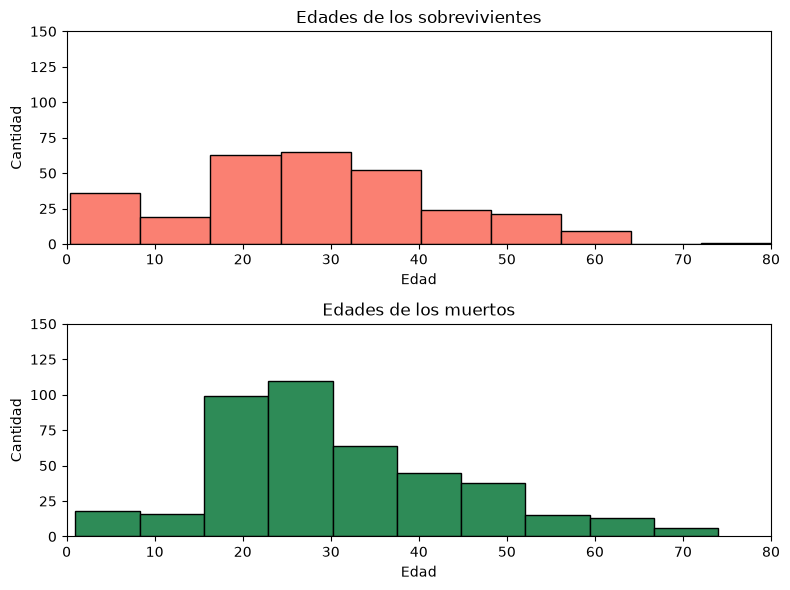

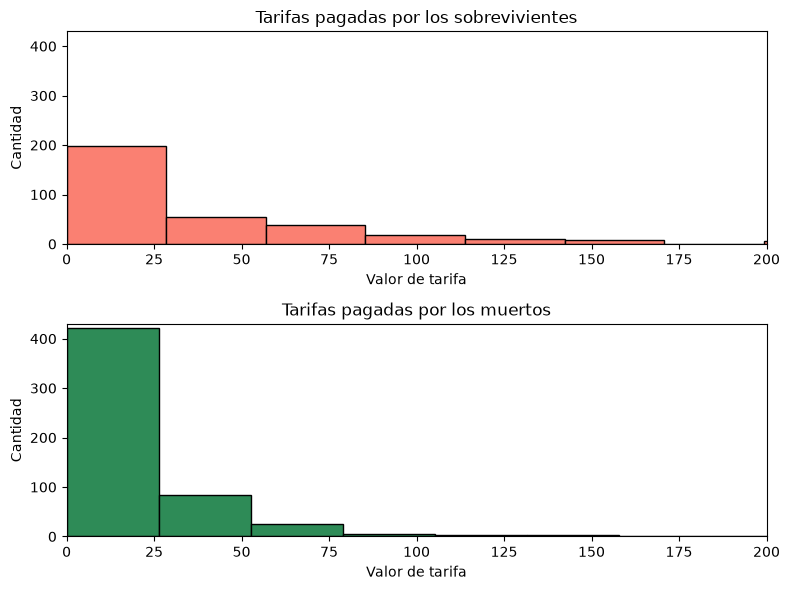

In [8]:
sobrevivientes = pasajeros[pasajeros["Survived"] == 1]
muertos = pasajeros[pasajeros["Survived"] == 0]

fig, axs = plt.subplots(nrows= 2, ncols=1,figsize = (8,6))

sobrevivientes["Age"].plot(kind = "hist", edgecolor = "black", color = "salmon", ax = axs[0])
axs[0].set_title("Edades de los sobrevivientes")
axs[0].set_ylabel("Cantidad")
axs[0].set_xlabel("Edad")
axs[0].set_xlim((0,80))
axs[0].set_ylim((0,150))

muertos["Age"].plot(kind = "hist", edgecolor = "black", ax = axs[1],color = "seagreen")
axs[1].set_title("Edades de los muertos")
axs[1].set_ylabel("Cantidad")
axs[1].set_xlabel("Edad")
axs[1].set_xlim((0,80))
axs[1].set_ylim((0,150))

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(nrows= 2, ncols=1,figsize = (8,6))

sobrevivientes["Fare"].plot(kind = "hist", edgecolor = "black", color = "salmon", ax = axs[0], bins = 18)
axs[0].set_title("Tarifas pagadas por los sobrevivientes")
axs[0].set_ylabel("Cantidad")
axs[0].set_xlabel("Valor de tarifa")
axs[0].set_xlim((0,200))
axs[0].set_ylim((0,430))

muertos["Fare"].plot(kind = "hist", edgecolor = "black", ax = axs[1],color = "seagreen")
axs[1].set_title("Tarifas pagadas por los muertos")
axs[1].set_ylabel("Cantidad")
axs[1].set_xlabel("Valor de tarifa")
axs[1].set_xlim((0,200))
axs[1].set_ylim((0,430))
plt.tight_layout()
plt.show()

Grafico de sexo y clases, según supervivencia

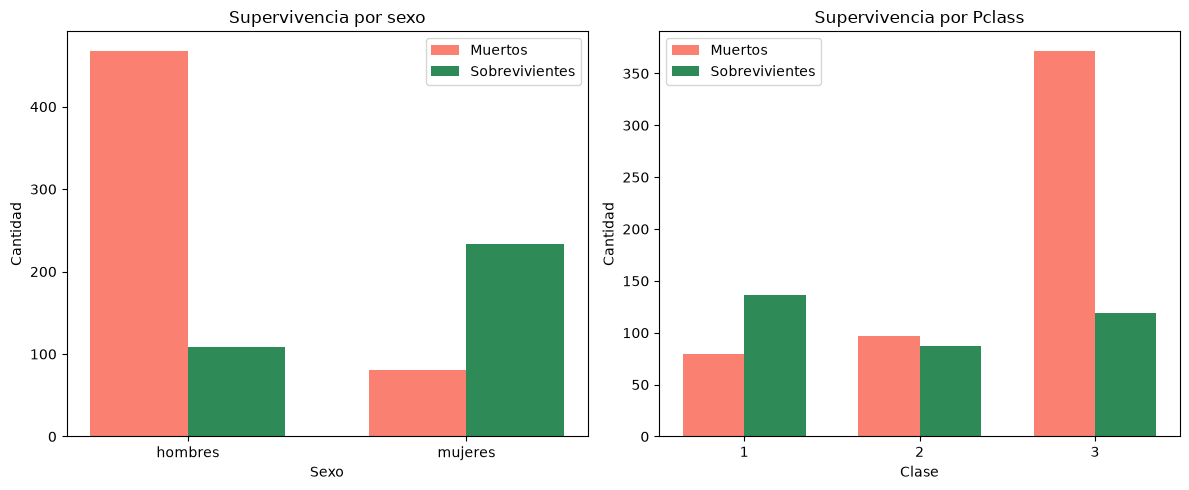

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
survived_by_sex = pasajeros.groupby('Sex')['Survived'].value_counts().unstack(fill_value=0)

# Gráfico 1: por sexo (hombres, mujeres)
df_sex = survived_by_sex.reindex(['male', 'female'])
x = np.arange(len(df_sex))
width = 0.35
axes[0].bar(x - width/2, df_sex[0], width, label='Muertos', color='salmon')
axes[0].bar(x + width/2, df_sex[1], width, label='Sobrevivientes', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['hombres', 'mujeres'])
axes[0].set_title('Supervivencia por sexo')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('Sexo')
axes[0].legend()

# Gráfico 2: por Pclass (1,2,3)
surv_pclass = pasajeros.groupby('Pclass')['Survived'].value_counts().unstack(fill_value=0).sort_index()
x2 = np.arange(len(surv_pclass))
axes[1].bar(x2 - width/2, surv_pclass[0], width, label='Muertos', color='salmon')
axes[1].bar(x2 + width/2, surv_pclass[1], width, label='Sobrevivientes', color='seagreen')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(surv_pclass.index.astype(str))
axes[1].set_title('Supervivencia por Pclass')
axes[1].set_ylabel('Cantidad')
axes[1].set_xlabel('Clase')
axes[1].legend()

plt.tight_layout()
plt.show()

Podemos observar en estos gráficos cierta relación entre el sexo, la tarifa pagada y la clase. Algo que intuitivamente podiamos esperar.

## Construcción del modelo

In [ ]:

y_train = pasajeros["Survived"].values
X_train = pasajeros.drop(columns=['Survived','Name'])


X_train['Cabin'] = X_train['Cabin'].fillna("unknown")


Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin         0
Embarked      2
dtype: int64

In [73]:
numericos_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categoricos_pipline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoding",OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer([
    ("num", numericos_pipeline, ["Age","Pclass","SibSp","Parch","Fare"]),
    ("cat", categoricos_pipline, ["Embarked", "Sex","Ticket","Cabin"])
])

pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("clasificador", RandomForestClassifier(random_state = 0))
])

param_grid = [{"clasificador__max_depth": [5,10,20,30,50],
              "clasificador__n_estimators":[50,100,200,400,800],
              "clasificador__criterion":["gini","entropy"]}]
        


grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best params:\n{}\n".format(grid.best_params_))



Best cross-validation score: 0.84
Best params:
{'clasificador__criterion': 'gini', 'clasificador__max_depth': 50, 'clasificador__n_estimators': 200}



839
839


<Axes: >

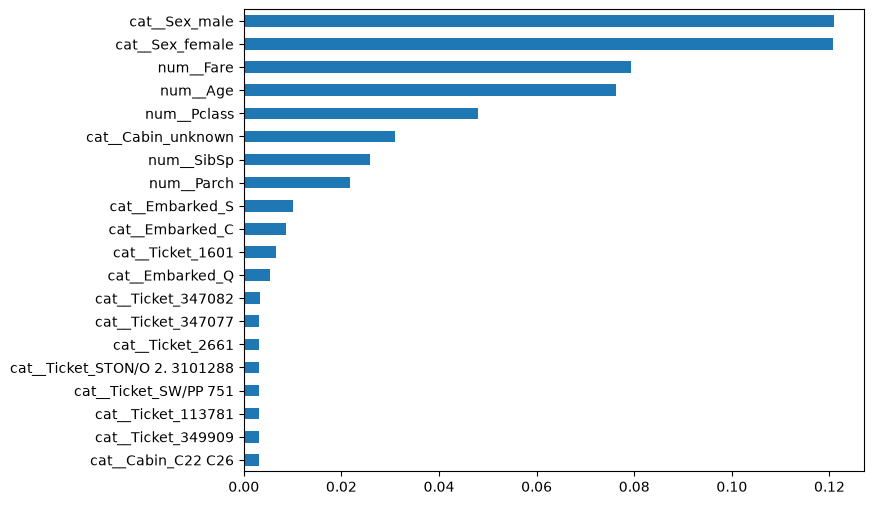

In [77]:
best_model = grid.best_estimator_.named_steps["clasificador"]
feature_names = grid.best_estimator_.named_steps["preprocessing"].get_feature_names_out()
print(len(feature_names))

print(len(best_model.feature_importances_))

importance = pd.Series(
    best_model.feature_importances_,
    index=feature_names
)

importance = importance.sort_values(ascending=False)[:20]

importance.sort_values().plot(kind="barh", figsize=(8,6))

In [105]:
test =  pd.read_csv('data\\test.csv')
ids = test["PassengerId"].values
test = test.set_index("PassengerId")
X_test = test.drop(columns=['Name'])

X_test['Cabin'] = X_test['Cabin'].fillna("unknown")
pred = grid.predict(X_test)

df = pd.DataFrame({'PassengerId': ids, 'Survived': pred})

df.to_csv('data\\pred_submission.csv',header = True, index = False)